In [1]:
import sys
sys.path.insert(0, '..')

In [2]:
# Basic imports
import jax.numpy as np
import jax.random as jr
import jax.scipy as jsp
import jax
import numpy

jax.config.update("jax_enable_x64", True)


# Optimisation imports
import zodiax as zdx
import optax
import optimistix as optx

# dLux imports
import dLux as dl
import dLux.utils as dlu

# Visualisation imports
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib
import chainconsumer as cc

from astropy.io import fits
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS


%matplotlib inline
plt.rcParams['image.cmap'] = 'inferno'
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = 'lower'
plt.rcParams['figure.dpi'] = 72
plt.rcParams["font.size"] = 24

from detectors import *
from apertures import *
from models import *
from stats import posterior
from fitting import *
from plotting import *
from spectra import *

import interpax as ipx
from glob import glob


In [3]:
ddir = '../data/NICMOS-LAPL-DD2/LAPL_HOLEFLATS_DD2/'

fnames = glob(ddir+"*flh.fits")
fnames.sort()

In [48]:
flat = np.zeros((256, 256))
for f in fnames:
    flat = flat + np.array(fits.getdata(f,1), dtype=float)/len(fnames)

ADCZERO                    0.0 / analog-digital conversion zero level (DN)       [astropy.io.fits.card]


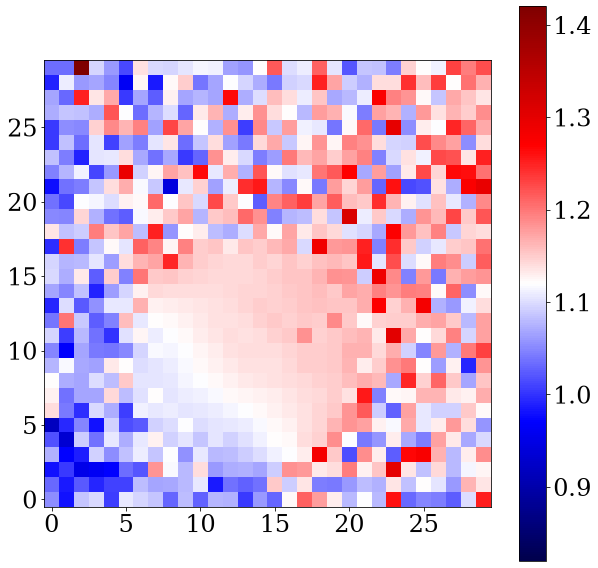

In [49]:
plt.figure(figsize=(10,10))
centre = 1.12
plt.imshow(flat[200:230, 60:90], cmap="seismic", vmax=centre+0.3, vmin=centre-0.3)
plt.colorbar()

In [61]:
flat = fits.getdata(fnames[0],1)

ADCZERO                    0.0 / analog-digital conversion zero level (DN)       [astropy.io.fits.card]


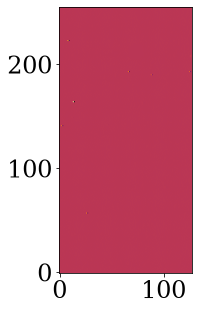

In [63]:
plt.imshow((flat[:,1:]-flat[:,:-1])[:,:128])

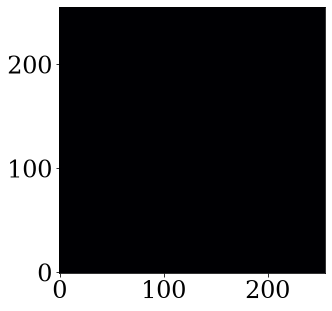

In [60]:
plt.imshow((np.array(fits.getdata(fnames[0],3), dtype=int)&1))


In [66]:
holeflat = flat[200:230, 60:90]

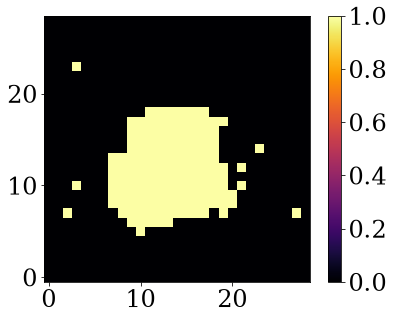

In [ ]:
thresh = 0.006
plt.imshow((np.abs((holeflat[:,1:]-holeflat[:,:-1]))[:-1,:]<thresh) & (np.abs((holeflat[1:,:]-holeflat[:-1,:]))[:,:-1]<thresh))
plt.colorbar()